In [1]:
import pandas as pd 
import numpy as np

all_methods = ['kt_gaussian', 'iid', 'kt_matern', 'kt_sobolev', 'kt_inverse_multiquadric', 'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified']

# Figure 8

In [8]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'stein_thinning', 'arfpy', 'influence']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================== CONFIG ==================
output_root = "Image8"
palette = "GnBu"

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

# ================== MEDIAN ANNOTATION ==================
def annotate_medians(ax, data, x, y, hue, palette):
    medians = (
        data
        .groupby([x, hue])[y]
        .median()
        .reset_index()
    )

    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    hue_levels = sorted(data[hue].dropna().unique())

    n_hue = len(hue_levels)
    width = 0.8
    step = width / n_hue

    colors = sns.color_palette(palette, n_hue)

    for _, row in medians.iterrows():
        x_pos = xlabels.index(row[x])
        hue_pos = hue_levels.index(row[hue])

        xpos = (
            xticks[x_pos]
            - width / 2
            + step / 2
            + hue_pos * step
        )

        r, g, b = colors[hue_pos]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(
            xpos,
            row[y],
            f"{row[y]:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

# ================== MAIN LOOP ==================
all_explainers = results_with_improvements["explainer_total"].unique()

os.makedirs(output_root, exist_ok=True)

for metric in metrics_to_analyze:
    metric_col = f"{metric}_pct_reduction"
    if metric_col not in results_with_improvements.columns:
        continue

    metric_dir = os.path.join(output_root, metric)
    os.makedirs(metric_dir, exist_ok=True)

    # ---- robust y-limits per metric ----
    q_low = results_with_improvements[metric_col].quantile(0.02)
    q_high = results_with_improvements[metric_col].quantile(0.98)
    padding = 0.05 * (q_high - q_low)

    y_min = q_low - padding
    y_max = 110

    for explainer in all_explainers:
        fig, axes = plt.subplots(2, 2, figsize=(20, 14))
        fig.suptitle(
            f"{metric} — Explainer: {explainer}",
            fontsize=18,
            fontweight="bold",
            y=1.02
        )

        for ax in axes.flat:
            ax.set_ylim(y_min, y_max)
            ax.axhline(0, linestyle="--", color="red", alpha=0.4)

        # ---------- NN - Regression ----------
        ax1 = axes[0, 0]
        data_nn_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_reg.empty:
            sns.boxplot(
                data=data_nn_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax1,
                palette=palette
            )
            annotate_medians(
                ax1, data_nn_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax1.set_title("NN - Regression")
        ax1.set_ylabel(f"{metric} % reduction")
        ax1.tick_params(axis="x", rotation=45)
        ax1.legend(title="Compression")

        # ---------- NN - Classification ----------
        ax2 = axes[0, 1]
        data_nn_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_clf.empty:
            sns.boxplot(
                data=data_nn_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax2,
                palette=palette
            )
            annotate_medians(
                ax2, data_nn_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax2.set_title("NN - Classification")
        ax2.set_ylabel("")
        ax2.tick_params(axis="x", rotation=45)
        ax2.legend(title="Compression")

        # ---------- XGBoost - Regression ----------
        ax3 = axes[1, 0]
        data_xgb_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_reg.empty:
            sns.boxplot(
                data=data_xgb_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax3,
                palette=palette
            )
            annotate_medians(
                ax3, data_xgb_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax3.set_title("XGBoost - Regression")
        ax3.set_xlabel("Method")
        ax3.set_ylabel(f"{metric} % reduction")
        ax3.tick_params(axis="x", rotation=45)
        ax3.legend(title="Compression")

        # ---------- XGBoost - Classification ----------
        ax4 = axes[1, 1]
        data_xgb_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_clf.empty:
            sns.boxplot(
                data=data_xgb_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax4,
                palette=palette
            )
            annotate_medians(
                ax4, data_xgb_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax4.set_title("XGBoost - Classification")
        ax4.set_xlabel("Method")
        ax4.set_ylabel("")
        ax4.tick_params(axis="x", rotation=45)
        ax4.legend(title="Compression")

        plt.tight_layout()

        fname = f"{explainer}.png"
        plt.savefig(os.path.join(metric_dir, fname), dpi=300, bbox_inches="tight")
        plt.close()


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3118177948.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3118177948.py:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3118177948.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3118177948.py:216: UserWarning: No artists with labels found to put in lege

# Figure 7

In [10]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_predictions']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================== CONFIG ==================
output_root = "Image7"
palette = "GnBu"

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

# ================== MEDIAN ANNOTATION ==================
def annotate_medians(ax, data, x, y, hue, palette):
    medians = (
        data
        .groupby([x, hue])[y]
        .median()
        .reset_index()
    )

    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    hue_levels = sorted(data[hue].dropna().unique())

    n_hue = len(hue_levels)
    width = 0.8
    step = width / n_hue

    colors = sns.color_palette(palette, n_hue)

    for _, row in medians.iterrows():
        x_pos = xlabels.index(row[x])
        hue_pos = hue_levels.index(row[hue])

        xpos = (
            xticks[x_pos]
            - width / 2
            + step / 2
            + hue_pos * step
        )

        r, g, b = colors[hue_pos]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(
            xpos,
            row[y],
            f"{row[y]:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

# ================== MAIN LOOP ==================
all_explainers = results_with_improvements["explainer_total"].unique()

os.makedirs(output_root, exist_ok=True)

for metric in metrics_to_analyze:
    metric_col = f"{metric}_pct_reduction"
    if metric_col not in results_with_improvements.columns:
        continue

    metric_dir = os.path.join(output_root, metric)
    os.makedirs(metric_dir, exist_ok=True)

    # ---- robust y-limits per metric ----
    q_low = results_with_improvements[metric_col].quantile(0.02)
    q_high = results_with_improvements[metric_col].quantile(0.98)
    padding = 0.05 * (q_high - q_low)

    y_min = q_low - padding
    y_max = 110

    for explainer in all_explainers:
        fig, axes = plt.subplots(2, 2, figsize=(20, 14))
        fig.suptitle(
            f"{metric} — Explainer: {explainer}",
            fontsize=18,
            fontweight="bold",
            y=1.02
        )

        for ax in axes.flat:
            ax.set_ylim(y_min, y_max)
            ax.axhline(0, linestyle="--", color="red", alpha=0.4)

        # ---------- NN - Regression ----------
        ax1 = axes[0, 0]
        data_nn_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_reg.empty:
            sns.boxplot(
                data=data_nn_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax1,
                palette=palette
            )
            annotate_medians(
                ax1, data_nn_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax1.set_title("NN - Regression")
        ax1.set_ylabel(f"{metric} % reduction")
        ax1.tick_params(axis="x", rotation=45)
        ax1.legend(title="Compression")

        # ---------- NN - Classification ----------
        ax2 = axes[0, 1]
        data_nn_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_clf.empty:
            sns.boxplot(
                data=data_nn_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax2,
                palette=palette
            )
            annotate_medians(
                ax2, data_nn_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax2.set_title("NN - Classification")
        ax2.set_ylabel("")
        ax2.tick_params(axis="x", rotation=45)
        ax2.legend(title="Compression")

        # ---------- XGBoost - Regression ----------
        ax3 = axes[1, 0]
        data_xgb_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_reg.empty:
            sns.boxplot(
                data=data_xgb_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax3,
                palette=palette
            )
            annotate_medians(
                ax3, data_xgb_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax3.set_title("XGBoost - Regression")
        ax3.set_xlabel("Method")
        ax3.set_ylabel(f"{metric} % reduction")
        ax3.tick_params(axis="x", rotation=45)
        ax3.legend(title="Compression")

        # ---------- XGBoost - Classification ----------
        ax4 = axes[1, 1]
        data_xgb_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_clf.empty:
            sns.boxplot(
                data=data_xgb_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax4,
                palette=palette
            )
            annotate_medians(
                ax4, data_xgb_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax4.set_title("XGBoost - Classification")
        ax4.set_xlabel("Method")
        ax4.set_ylabel("")
        ax4.tick_params(axis="x", rotation=45)
        ax4.legend(title="Compression")

        plt.tight_layout()

        fname = f"{explainer}.png"
        plt.savefig(os.path.join(metric_dir, fname), dpi=300, bbox_inches="tight")
        plt.close()


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/310678964.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/310678964.py:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/310678964.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/310678964.py:216: UserWarning: No artists with labels found to put in legend. 

# Figure 6

In [12]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [13]:
import matplotlib.pyplot as plt
import os

# создаём папку для сохранения, если нет
os.makedirs("Image9", exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.35

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    # вычисляем среднее улучшение по non-iid методам
    mean_improvement_by_config = (
        results_with_improvements[
            results_with_improvements["method_total"] != "iid"
        ]
        .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
        .mean()
        .mean(axis=1)
        .reset_index(name="mean_improvement_not_iid")
    )

    df = mean_improvement_by_config.copy()

    explainers = df["explainer_total"].unique()
    models = df["model_name"].unique()

    fig, axes = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
    axes = axes.flatten()

    for ax, explainer in zip(axes, explainers):
        sub = df[df["explainer_total"] == explainer]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]

            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement_not_iid",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 1.5,
                        f"{h:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=12,
                    )

        ax.set_title(f"Explainer: {explainer}", fontsize=14)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=12)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % improvement vs IID", fontsize=12)

    axes[0].legend(frameon=False, fontsize=12)
    fig.suptitle(f"{metric} improvement vs IID", fontsize=16, y=1.02)
    plt.tight_layout()

    # сохраняем фигуру
    plt.savefig(f"Image9/{metric}_improvement.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 9

In [2]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [15]:
import matplotlib.pyplot as plt
import os

output_dir = "./Image9"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.35

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    mean_improvement_by_config = (
        results_with_improvements[
            results_with_improvements["method_total"] != "iid"
        ]
        .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
        .mean()
        .mean(axis=1)
        .reset_index(name="mean_improvement_not_iid")
    )

    df = mean_improvement_by_config.copy()

    explainers = df["explainer_total"].unique()
    models = df["model_name"].unique()

    fig, axes = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
    axes = axes.flatten()

    for ax, explainer in zip(axes, explainers):
        sub = df[df["explainer_total"] == explainer]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]

            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement_not_iid",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 1.5,
                        f"{h:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=12,
                    )

        ax.set_title(f"Explainer: {explainer}", fontsize=14)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=12)
        if metric in ["mae_mean", "mae_std", "top_k_std", "mmd_mean"]:
            ax.set_ylim(0, 110)
        if metric in ["top_k_mean"]:
            ax.set_ylim(-100, 0)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % reduction vs IID", fontsize=12)

    axes[0].legend(frameon=False, fontsize=12)
    fig.suptitle(f"{metric} reduction vs IID", fontsize=16, y=1.02)
    plt.tight_layout()

    plt.savefig(f"Image9/{metric}_reduction.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


In [16]:
import matplotlib.pyplot as plt
import os
import math

output_dir = "./Image10"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]
tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.25
y_margin = 5

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[
                results_with_improvements["method_total"] == method
            ]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)
    explainers = df_all["explainer_total"].unique()
    models = df_all["model_name"].unique()

    all_values = df_all["mean_improvement"].values
    y_min = min(all_values) - y_margin
    y_max = max(all_values) + y_margin

    n_subplots = len(explainers) * len(methods_to_plot)
    n_cols = 4
    n_rows = math.ceil(n_subplots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4), sharey=True)
    axes = axes.flatten()

    for idx, (method, explainer) in enumerate([(m, e) for m in methods_to_plot for e in explainers]):
        ax = axes[idx]
        sub = df_all[(df_all["explainer_total"] == explainer) & (df_all["method_total"] == method)]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]
            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + (1 if h >= 0 else -3),
                    f"{h:.1f}",
                    ha="center",
                    va="bottom" if h >= 0 else "top",
                    fontsize=10,
                )

        ax.set_title(f"{method} — {explainer}", fontsize=12)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=10)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % reduction vs IID", fontsize=10)

    for j in range(idx+1, len(axes)):
        fig.delaxes(axes[j])

    axes[0].legend(frameon=False, fontsize=10)
    fig.suptitle(f"{metric} reduction vs IID", fontsize=16, y=1.02)
    plt.tight_layout()

    plt.savefig(f"{output_dir}/{metric}_all_methods_reduction.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3825422525.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_7736/3825422525.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


# Image 11

In [17]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# run cell below "Image 9"

output_dir = "./Image11"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "kt_sobolev"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_matern": "#59A14F",
    "kt_inverse_multiquadric": "#F28E2B",
    "kt_sobolev": "#E15759",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
    "kt_sobolev": "KT (Sobolev)",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

# Only top_k_mean uses "improvement" (higher is better)
metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k reduction vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
y_margin = 5

# Formatting controls for bar labels
zero_tol = 1e-12        # treat values with abs(v) <= zero_tol as zero -> no label
label_min_abs = 0.05    # don't label tiny bars (helps readability); set 0.0 to label all nonzero

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    # Flip sign only for top_k_mean (so higher is better)
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[results_with_improvements["method_total"] == method]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)

    # Stable 1x4 explainer order (only those present)
    explainer_order = list(explainer_labels.keys())
    explainers = [e for e in explainer_order if e in df_all["explainer_total"].unique()]
    models = sorted(df_all["model_name"].unique())

    # Apply sign flip to aggregated values (only for top_k_mean)
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]

    all_vals = df_all["mean_improvement"].values
    y_min, y_max = float(np.min(all_vals))*0.90, float(np.max(all_vals))*1.1 #float(np.min(all_vals)) - y_margin, float(np.max(all_vals)) + y_margin

    # 1x4 layout; make std plots larger (they often have small magnitudes)
    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(
        1,
        len(explainers),
        figsize=(fig_w, fig_h),
        sharey=True,
    )
    if len(explainers) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Bars: methods * tasks per model
    bar_group_width = 0.90 if is_std else 0.82
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))

    for idx, explainer in enumerate(explainers):
        ax = axes[idx]
        sub = df_all[df_all["explainer_total"] == explainer]

        x = np.arange(len(models))
        bar_i = 0

        for method in methods_to_plot:
            for task in tasks:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]

                values = [
                    float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                    if m in task_sub["model_name"].values
                    else 0.0
                    for m in models
                ]

                offsets = (bar_i - (len(methods_to_plot) * len(tasks) - 1) / 2) * bar_w
                xpos = x + offsets

                bars = ax.bar(
                    xpos,
                    values,
                    width=bar_w,
                    color=method_colors[method],
                    edgecolor=edgecolor,
                    hatch=task_hatch[task],
                    linewidth=1.1,
                )

                # Always show labels (including std), but never show 0.0 labels
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h + (1 if h >= 0 else -3),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=9, 
                    )

                bar_i += 1

        ax.set_title(explainer_labels.get(explainer, explainer), fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, "Mean % change vs IID"), fontsize=12)

    # Legend: methods (colors) + tasks (hatches)
    method_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot
    ]
    task_handles = [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[0].legend(
        handles=method_handles + task_handles,
        frameon=False,
        fontsize=11,
        loc="upper right",
    )

    # Title: make top_k_mean wording consistent with sign flip
    title = metric_titles.get(metric, metric)
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Kernel choice in Kernel Thinning — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_1x4_combined_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 13

In [18]:
results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', "kt_stratified", "kt_predictions"]
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'target_size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [19]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./Image13"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

methods_to_plot = ["kt_gaussian", "kt_stratified", "kt_predictions"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_stratified": "#59A14F",
    "kt_predictions": "#F28E2B",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_stratified": "KT Stratified",
    "kt_predictions": "KT Predictions",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

# Only top_k_mean uses "improvement" (higher is better)
metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k reduction vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
y_margin = 5

# Formatting controls for bar labels
zero_tol = 1e-12        # treat values with abs(v) <= zero_tol as zero -> no label
label_min_abs = 0.05    # don't label tiny bars (helps readability); set 0.0 to label all nonzero

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    # Flip sign only for top_k_mean (so higher is better)
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[results_with_improvements["method_total"] == method]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)

    # Stable 1x4 explainer order (only those present)
    explainer_order = list(explainer_labels.keys())
    explainers = [e for e in explainer_order if e in df_all["explainer_total"].unique()]
    models = sorted(df_all["model_name"].unique())

    # Apply sign flip to aggregated values (only for top_k_mean)
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]

    all_vals = df_all["mean_improvement"].values
    y_min, y_max = float(np.min(all_vals))*0.90, float(np.max(all_vals))*1.1 #float(np.min(all_vals)) - y_margin, float(np.max(all_vals)) + y_margin

    # 1x4 layout; make std plots larger (they often have small magnitudes)
    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(
        1,
        len(explainers),
        figsize=(fig_w, fig_h),
        sharey=True,
    )
    if len(explainers) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Bars: methods * tasks per model
    bar_group_width = 0.90 if is_std else 0.82
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))

    for idx, explainer in enumerate(explainers):
        ax = axes[idx]
        sub = df_all[df_all["explainer_total"] == explainer]

        x = np.arange(len(models))
        bar_i = 0

        for method in methods_to_plot:
            for task in tasks:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]

                values = [
                    float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                    if m in task_sub["model_name"].values
                    else 0.0
                    for m in models
                ]

                offsets = (bar_i - (len(methods_to_plot) * len(tasks) - 1) / 2) * bar_w
                xpos = x + offsets

                bars = ax.bar(
                    xpos,
                    values,
                    width=bar_w,
                    color=method_colors[method],
                    edgecolor=edgecolor,
                    hatch=task_hatch[task],
                    linewidth=1.1,
                )

                # Always show labels (including std), but never show 0.0 labels
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h + (1 if h >= 0 else -3),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=9, 
                    )

                bar_i += 1

        ax.set_title(explainer_labels.get(explainer, explainer), fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, "Mean % change vs IID"), fontsize=12)

    # Legend: methods (colors) + tasks (hatches)
    method_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot
    ]
    task_handles = [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[0].legend(
        handles=method_handles + task_handles,
        frameon=False,
        fontsize=11,
        loc="upper right",
    )

    # Title: make top_k_mean wording consistent with sign flip
    title = metric_titles.get(metric, metric)
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Kernel choice in Kernel Thinning — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_1x4_combined_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 14

In [20]:
results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")
all_methods = ['kt_gaussian', 'iid', 'kt_matern', 'kt_sobolev', 'kt_inverse_multiquadric', 'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'target_size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [21]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from itertools import cycle

output_dir = "./Image14"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

methods_to_plot = [
    'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric',
    'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified'
]

tasks = ["regression", "classification"]

# ---------- COLORS: auto-generate ----------
palette = plt.get_cmap("tab10")
method_colors = {
    m: palette(i % palette.N) for i, m in enumerate(methods_to_plot)
}

# ---------- LABELS: readable defaults ----------
def prettify_method(m):
    return m.replace("_", " ").replace("kt", "KT").title()

method_labels = {m: prettify_method(m) for m in methods_to_plot}

# Optional overrides (keep nice names where needed)
method_labels.update({
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
    "kt_predictions": "KT (Predictions)",
    "kt_stratified": "KT (Stratified)",
    "arfpy": "ARF",
})

task_hatch = {
    "regression": None,
    "classification": "//",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k change vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        sub = results_with_improvements[
            results_with_improvements["method_total"] == method
        ]
        if sub.empty:
            continue

        df_method = (
            sub.groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    if not dfs:
        continue

    df_all = pd.concat(dfs, ignore_index=True)

    if flip_sign:
        df_all["mean_improvement"] *= -1

    explainers = [
        e for e in explainer_labels
        if e in df_all["explainer_total"].unique()
    ]
    models = sorted(df_all["model_name"].unique())

    vals = df_all["mean_improvement"].values
    y_min = min(0, np.min(vals) * 0.9)
    y_max = np.max(vals) * 1.1

    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(1, len(explainers), figsize=(fig_w, fig_h), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    bar_group_width = 0.90 if is_std else 0.82
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))

    for i, explainer in enumerate(explainers):
        ax = axes[i]
        sub = df_all[df_all["explainer_total"] == explainer]

        x = np.arange(len(models))
        bar_i = 0

        for method in methods_to_plot:
            for task in tasks:
                tmp = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                values = [
                    tmp.loc[tmp["model_name"] == m, "mean_improvement"].values[0]
                    if m in tmp["model_name"].values else 0.0
                    for m in models
                ]

                xpos = x + (bar_i - (len(methods_to_plot)*len(tasks)-1)/2) * bar_w

                bars = ax.bar(
                    xpos, values, bar_w,
                    color=method_colors[method],
                    hatch=task_hatch[task],
                    edgecolor=edgecolor,
                    linewidth=1.0,
                )

                for b in bars:
                    h = b.get_height()
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width()/2,
                        h + (1 if h >= 0 else -3),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=9,
                    )

                bar_i += 1

        ax.set_title(explainer_labels[explainer], fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if i == 0:
            ax.set_ylabel(metric_ylabels[metric], fontsize=12)

    legend_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot if m in df_all["method_total"].unique()
    ] + [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[0].legend(
        handles=legend_handles,
        frameon=False,
        fontsize=11,
        loc="upper right",
    )

    title = metric_titles[metric]
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Comparison of compression methods — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 15 - pdf version of image 11 - combined

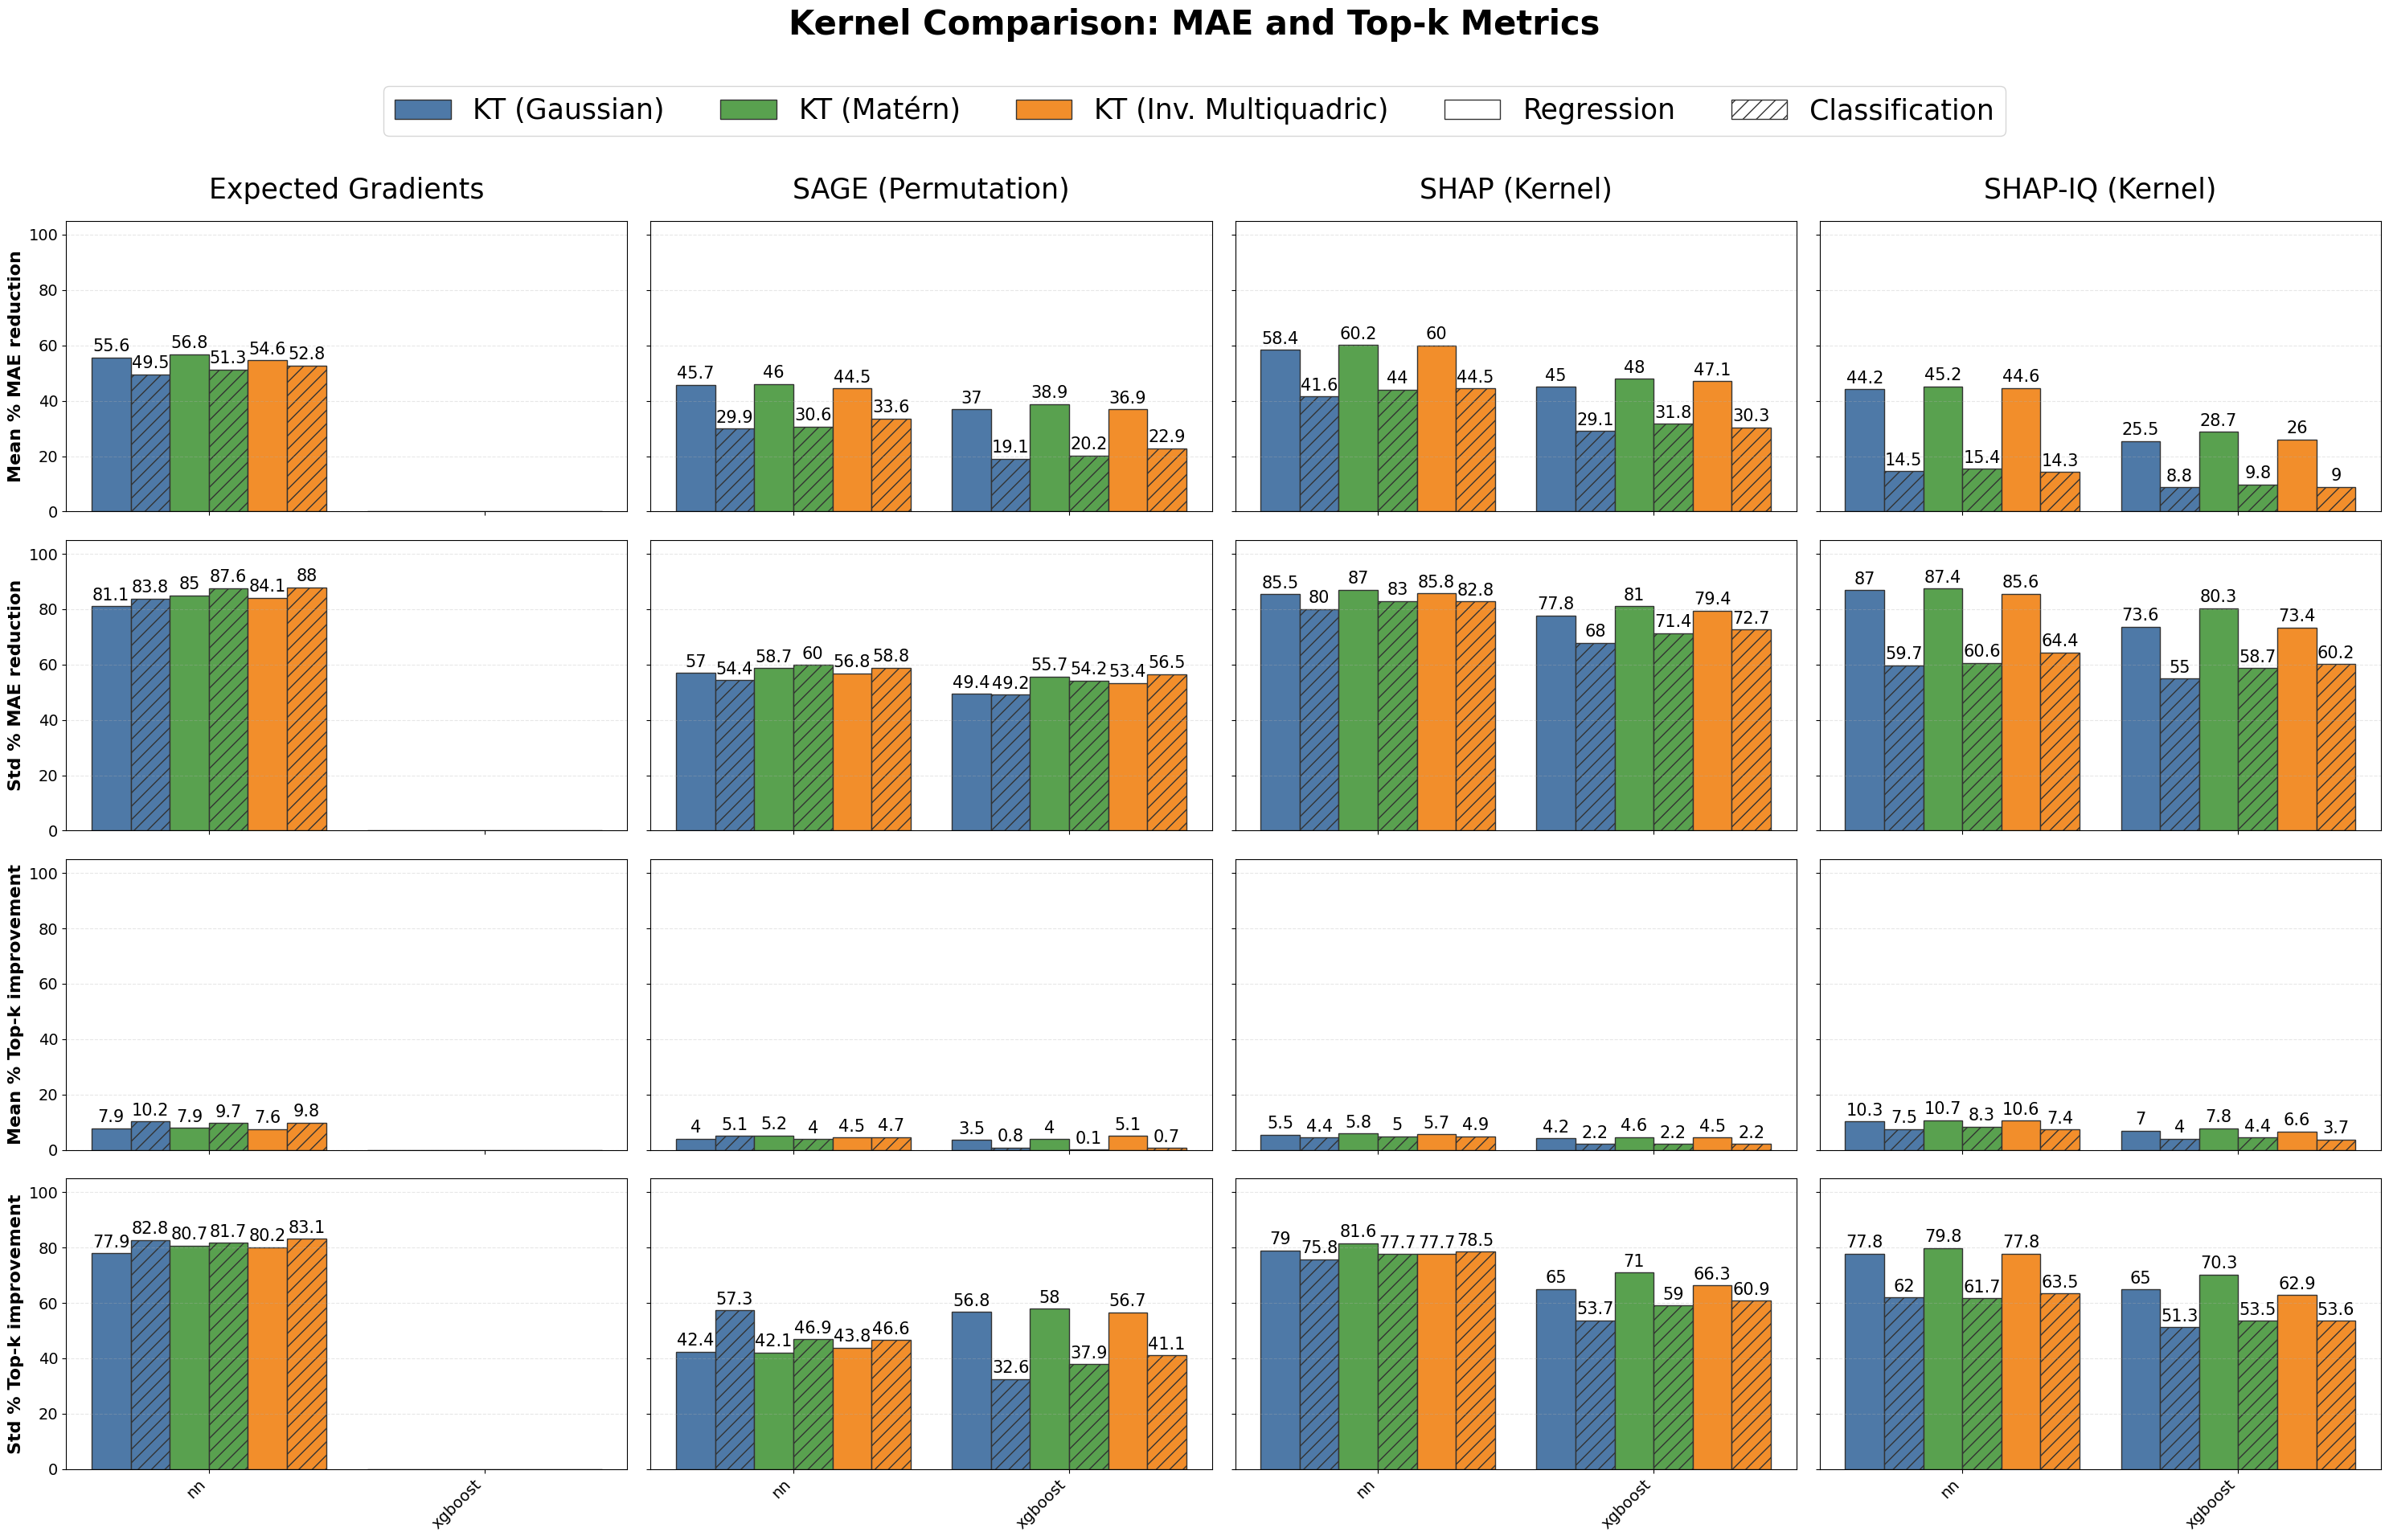

In [13]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./Image15"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "mae_std", 
    "top_k_mean",
    "top_k_std",
]

methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_matern": "#59A14F", 
    "kt_inverse_multiquadric": "#F28E2B",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "mae_std": "MAE (std)",
    "top_k_mean": "Top-k agreement (mean)",
    "top_k_std": "Top-k agreement (std)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction",
    "mae_std": "Std % MAE reduction",
    "top_k_mean": "Mean % Top-k improvement",
    "top_k_std": "Std % Top-k improvement",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05
all_metric_data = {}

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    
    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[results_with_improvements["method_total"] == method]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)
    
    df_all = pd.concat(dfs, ignore_index=True)
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]
    
    sample_values = df_all["mean_improvement"].head(10).values
    if all(abs(v) < 5 for v in sample_values if not np.isnan(v)):
        df_all["mean_improvement"] = df_all["mean_improvement"] * 100
    
    all_metric_data[metric] = df_all

explainers = ["expected_gradients", "sage_permutation", "shap_kernel", "shapiq_kernel"]
models = sorted(all_metric_data["mae_mean"]["model_name"].unique())

Y_MIN, Y_MAX = 0, 105

fig, axes = plt.subplots(4, 4, figsize=(30, 20), sharex=True, sharey=True)

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

for row_idx, metric in enumerate(metrics_to_analyze):
    df_all = all_metric_data[metric]
    is_std = metric.endswith("_std")
    
    bar_group_width = 0.85
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))
    
    for col_idx, explainer in enumerate(explainers):
        ax = axes[row_idx, col_idx]
        sub = df_all[df_all["explainer_total"] == explainer]
        x = np.arange(len(models))
        bar_i = 0
        
        for method in methods_to_plot:
            for task in tasks:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                values = []
                for m in models:
                    if m in task_sub["model_name"].values:
                        val = float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                        values.append(max(min(val, Y_MAX), Y_MIN))
                    else:
                        values.append(0.0)
                
                offsets = (bar_i - (len(methods_to_plot) * len(tasks) - 1) / 2) * bar_w
                bars = ax.bar(x + offsets, values, width=bar_w, color=method_colors[method],
                              edgecolor=edgecolor, hatch=task_hatch[task], linewidth=1.0)
                
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) < label_min_abs: continue
                    text = f"{int(round(h))}" if abs(h - round(h)) < 0.1 else f"{h:.1f}"
                    ax.text(b.get_x() + b.get_width() / 2, h + 1.0, text, 
                            ha="center", va='bottom', fontsize=15)
                bar_i += 1
        
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        
        if row_idx == 0:
            ax.set_title(explainer_labels.get(explainer, explainer), fontsize=25, pad=20)
        if col_idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, metric), fontsize=16, fontweight='bold')

method_handles = [Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m]) for m in methods_to_plot]
task_handles = [Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize()) for t in tasks]

fig.legend(handles=method_handles + task_handles, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=len(methods_to_plot) + len(tasks), frameon=True, fontsize=25)

fig.suptitle("Kernel Comparison: MAE and Top-k Metrics", fontsize=30, y=0.98, fontweight='bold')

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig(f"{output_dir}/mae_topk_comparison_final.pdf", dpi=300, bbox_inches='tight')
plt.show()